# Tutorial 7 - Pandas, Numpy & Team Collaboration
### FINM3422 - Data Cleaning, Alignment, Multi‑Dataset Operations
---
This tutorial helps you build **real confidence** with Python, pandas, and numpy.
It is **not related to any assessment** - it builds generic modelling skills used in finance and data analysis.

You will:
- Clean small finance‑flavoured datasets
- Align dates & practice time‑series operations
- Merge DataFrames correctly
- Understand vectorisation vs loops
- Produce diagnostic charts
- Practice GitHub collaboration (branches + PRs) as a **team**

---

## 1. Environment Info

In [1]:
import sys, pandas as pd, numpy as np
print('Python:', sys.version)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)

Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.3.3


## 2. Imports & Settings

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme()

## 3. Generate Synthetic Finance‑Flavoured Datasets (No CSVs Needed)
We will create three small datasets directly in this notebook.
Each series mimics simple monthly price or return behaviour.

### ✅ Dataset A — Monthly prices for Asset A
### ✅ Dataset B — Monthly prices for Asset B
### ✅ Dataset C — Monthly returns for Asset C

Later, you will clean, align, merge, and analyse them.

In [ ]:
# Generate synthetic data
dates = pd.date_range(start='2021-01-01', periods=24, freq='M')

np.random.seed(0)     # Fix the RNG so each completion produces the same data
assetA = 100 * (1 + 0.01*np.random.randn(24)).cumprod() # Produce an array "assetA" of 24 price values, starting at 100, and iterating with cumproduct
assetB = 80 * (1 + 0.015*np.random.randn(24)).cumprod() # Produce an array "assetB" of 24 price values, starting at 80, and iterating with cumproduct
assetC_returns = np.random.normal(loc=0.01, scale=0.03, size=24)  # Produce an array of "assetC_returns" of 24 return values, with a mean of 0.01 
                                                                  # and a standard deviation of 0.03


# Create DataFrames for each asset, indexed by the "dates" DatetimeIndex
dfA = pd.DataFrame({'PriceA': assetA}, index=dates)
dfB = pd.DataFrame({'PriceB': assetB}, index=dates)
dfC = pd.DataFrame({'RetC': assetC_returns}, index=dates)

dfA.head()

C:\Users\Tom Macpherson\AppData\Local\Temp\ipykernel_2432\2834110887.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2021-01-01', periods=24, freq='M')


,PriceA
2021-01-31,101.7641
2021-02-28,102.1713
2021-03-31,103.1713
2021-04-30,105.4832
2021-05-31,107.4532


## 4. Inspection Tasks — *Team Split*
Assign ONE task per teammate. Add conclusions in markdown.

### ✅ Tasks:
- Inspect `.info()` on one dataset
- Inspect `.describe()`
- Check for missing values using `.isna().sum()`
- Check index type
- Infer frequency using `pd.infer_freq()`
- Check for duplicated dates using `.duplicated()`

In [9]:
# Example cell — students create their own below
# Create a new cell for each task and write code to complete the task. Run code and write conclusions in a markdown below the code cell.
# See example below for task 1 inspect.

Inspection Task 1 - dfA (Tom)

In [1]:
dfA.info()

NameError: name 'dfA' is not defined

Inspection Task 1 - dfA (Tom)

In [10]:
dfA.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PriceA  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes


Conclusions: dfA only has float data, which is ok for prices - no need to change anything

Inspection Task 2 - dfA (Tom)

In [12]:
dfA.describe()

,PriceA
count,24.0000
mean,108.5381
std,3.1491
min,101.7641
25%,107.2237
50%,109.1943
75%,110.7507
max,112.9085


Conclusions: Describe provides descriptive stats, mean price here is $108.54, min, max etc

Inspection Remaining Tasks  - dfA (Tom)

In [ ]:
# Check for empty values which show as nan in pandas (.isna checks for empties, .sum counts them)
dfA.isna().sum()

PriceA    0
dtype: int64

In [ ]:
# Check for duplicated dates (.index takes the index - the dates - of dfA, 
#                             .duplicated returns True for each dupe, 
#                             and .any returns True once if any dupes are found)
dfA.index.duplicated().any()

np.False_

In [ ]:
# Check what data type dfA is indexed on (shoud be DatetimeIndex). Again, .index takes the index of dfA
type(dfA.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [ ]:
# Check the frequency of the dates in dfA. This should be "ME" for month end
pd.infer_freq(dfA.index)

'ME'

## 5. Cleaning Tasks — *Team Split*
### Why we clean data
Real datasets contain issues: inconsistent dates, missing observations, incorrect datatypes.
Finance models fail if the underlying data is misaligned or dirty.

### ✅ Tasks (each member gets one):
- Convert index to true month‑end using `.to_period('M').to_timestamp('M')`
- Sort index and verify ascending order
- Forward fill missing prices (if any)
- Convert prices → returns using `.pct_change().dropna()`
- Convert string columns → numeric (if needed)
- Rename columns to standardised names (e.g., `PriceA`, `PriceB`, `RetC`)
- Add markdown describing what issue you fixed and why

In [ ]:
# Example transformation (students extend)

# Convert the index of dfA from dates to a months period with .to_period('M'),
# Move index points to month end timestamps with .to_timestamp('M'
dfA.index = dfA.index.to_period('M').to_timestamp('M')

# Sort dfA by index with .sort_index()
dfA = dfA.sort_index()
dfA.head()

,PriceA
2021-01-31,101.7641
2021-02-28,102.1713
2021-03-31,103.1713
2021-04-30,105.4832
2021-05-31,107.4532


In [25]:
# Verify ascending index order with .index.is_monotonic_increasing
dfA.index.is_monotonic_increasing

True

In [ ]:
# Forward fill empty values with .ffill(). Forward fill replaces each empty value with the most recent non-empty value.
dfA = dfA.ffill()

In [ ]:
# Calculate returns from prices with .pct_change() and drop the first row which is empty (no change in t=0) with .dropna()
retA = dfA.pct_change().dropna()

retA.head()

,PriceA
2021-02-28,0.0040
2021-03-31,0.0098
2021-04-30,0.0224
2021-05-31,0.0187
2021-06-30,-0.0098


In [ ]:
# Convert dfA price column to numerics with "pd.to_numeric()" (in case anything is a string). errors='coerce' makes non-convertibles return "nan"
dfA["PriceA"] = pd.to_numeric(dfA["PriceA"], errors='coerce')

In [33]:
dfA.columns = ["PriceA"]
dfA.head()

,PriceA
2021-01-31,101.7641
2021-02-28,102.1713
2021-03-31,103.1713
2021-04-30,105.4832
2021-05-31,107.4532


## 6. Time-Series Transformations 
### ✅ Compute simple monthly returns
### ✅ Wealth index
### ✅ Rolling averages/volatility
### ✅ Correlations between assets

These operations are used everywhere in finance, investment operations, and risk analysis.

In [ ]:
# Returns for A as above
retA = dfA.pct_change().dropna()

# Create a new array of a wealth index "wealthA" by adding 1 to returns and taking the cumulative product with .cumprod()
wealthA = (1 + retA['PriceA']).cumprod()
wealthA.head()

2021-02-28   1.0040
2021-03-31   1.0138
2021-04-30   1.0365
2021-05-31   1.0559
2021-06-30   1.0456
Freq: ME, Name: PriceA, dtype: float64

In [37]:
# Add another column on the returns index for a three month rolling avg. 
# .rolling(window=3) creates a rolling window of 3 months, and .mean() takes the average of each window
retA['Rolling 3M Avg'] = retA['PriceA'].rolling(window=3).mean()

# Add another column on the returns index for a 3 month rolling volatility
# .rolling(window=3) creates a rolling window of 3 months, and .std() takes the standard deviation of each window
retA['Rolling 3M Vol'] = retA['PriceA'].rolling(window=3).std()

retA.head(10)

,PriceA,Rolling 3M Avg,Rolling 3M Vol
2021-02-28,0.0040,NaN,NaN
2021-03-31,0.0098,NaN,NaN
2021-04-30,0.0224,0.0121,0.0094
2021-05-31,0.0187,0.0170,0.0065
2021-06-30,-0.0098,0.0104,0.0176
2021-07-31,0.0095,0.0061,0.0145
2021-08-31,-0.0015,-0.0006,0.0097
2021-09-30,-0.0010,0.0023,0.0062
2021-10-31,0.0041,0.0005,0.0031
2021-11-30,0.0014,0.0015,0.0026


In [ ]:
# Combine all returns into one DataFrame. I have not made the B and C returns yet so this is illustrative
# pd.concat() combines the three return series into one DataFrame, with axis=1 meaning they are combined as columns. axis=0 for rows
# rename the columns to RetA, RetB, and RetC
all_returns = pd.concat([retA['PriceA'], retB['PriceB'], dfC['RetC']], axis=1)
all_returns.columns = ['RetA', 'RetB', 'RetC']

# Compute correlation matrix as a new array named "corr_matrix" with .corr()
corr_matrix = all_returns.corr()
print(corr_matrix)

## 7. Merging / Joining Multiple DataFrames
Merging/joining datasets is crucial when combining sleeves, markets, or indicators.

### ✅ Try these joins:
- `inner` join
- `outer` join (shows missing dates if any)
- `left` join

Explain in markdown what difference you observed.

In [41]:
# Combine dfA and dfB with an inner join. Inner joins keep only rows where the index matches in both DataFrams
combined_inner = dfA.join(dfB, how='inner')
combined_inner.head()

,PriceA,PriceB
2021-01-31,101.7641,82.7237
2021-02-28,102.1713,80.9190
2021-03-31,103.1713,80.9746
2021-04-30,105.4832,80.7472
2021-05-31,107.4532,82.6037


In [ ]:
# Combined dfA and dfB with an outer join. Keeps all data from both frames.
# If a date exists in one but not the other, the missing side fills with NaN, these can be removed with .dropna() if desired
combined_outer = dfA.join(dfB, how='outer')
combined_outer.head()

,PriceA,PriceB
2021-01-31,101.7641,82.7237
2021-02-28,102.1713,80.9190
2021-03-31,103.1713,80.9746
2021-04-30,105.4832,80.7472
2021-05-31,107.4532,82.6037


In [43]:
# Combined dfA and dfB with a left join. Keeps all data from the left frame (dfA) and only matching data from the right frame (dfB)
# A right join is also possible with how='right' which keeps all data from the right frame and only matching data from the left frame
combined_left = dfA.join(dfB, how='left')
combined_left.head()

,PriceA,PriceB
2021-01-31,101.7641,82.7237
2021-02-28,102.1713,80.9190
2021-03-31,103.1713,80.9746
2021-04-30,105.4832,80.7472
2021-05-31,107.4532,82.6037


## 8. Vectorisation vs Loops
Vectorised operations in pandas/numpy are *much faster* than Python loops.
This matters in finance where datasets can be millions of rows.

### ✅ Compare performance, clarity, correctness.

In [ ]:
%%timeit
# Need to have %%timit in the first entry of the cell to time the whole cell
# Loop version loops around and appends a new row onto the out array one by one
out = []
for r in retA['PriceA']:
    out.append(r * 12)  # e.g., annualising monthly return (not exact)
loop_res = pd.Series(out, index=retA.index)

37.8 μs ± 309 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
%%timeit
# Vectorised version operates on the whole column at once
vec_res = retA['PriceA'] * 12

39.6 μs ± 706 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Vectorised is slower than loop here because it has a "fixed overhead" time, so on smaller datasets looping might be faster, but on large datasets vectorised is faster

## 9. Diagnostic Charts
Producing visual checks helps reveal missing data, misalignment, noise, or unusual movements.
Each team member creates **one chart**.

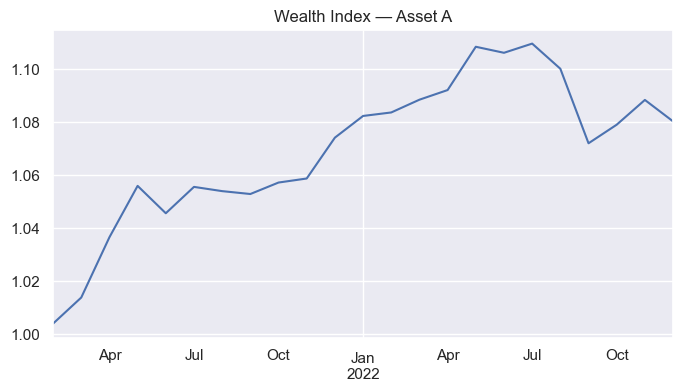

In [50]:
# Wealth index
wealthA.plot(title='Wealth Index — Asset A', figsize=(8,4))
plt.show()

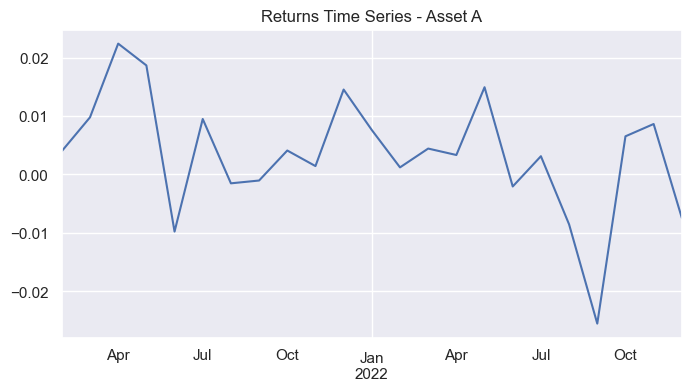

In [51]:
# Returns time series
retA['PriceA'].plot(title='Returns Time Series - Asset A', figsize=(8,4))
plt.show()


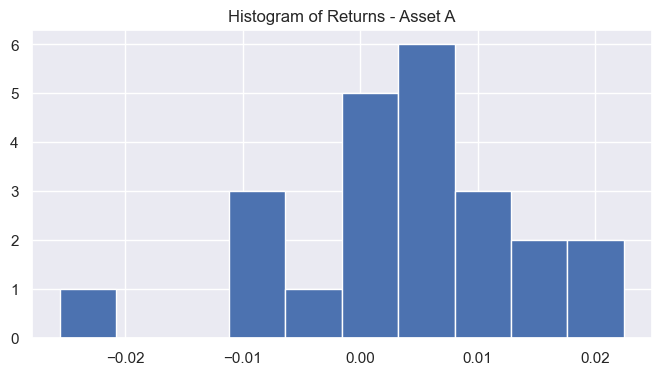

In [55]:
# Histogram of returns
retA['PriceA'].hist(figsize=(8,4))
plt.title('Histogram of Returns - Asset A')
plt.show()

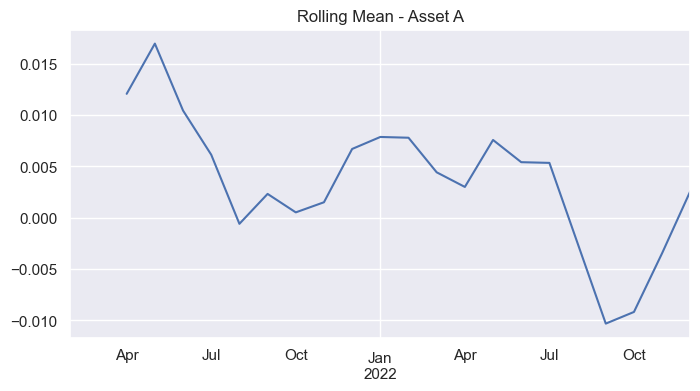

In [56]:
# Rolling mean
retA['PriceA'].rolling(window=3).mean().plot(title='Rolling Mean - Asset A', figsize=(8,4))
plt.show()


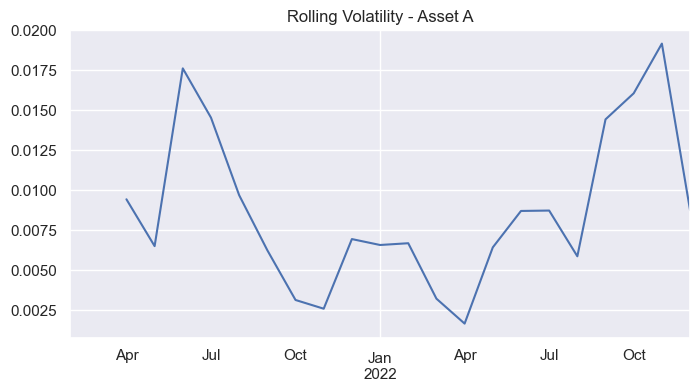

In [59]:
# Rolling vol
retA['PriceA'].rolling(window=3).std().plot(title='Rolling Volatility - Asset A', figsize=(8,4))
plt.show()


In [ ]:
# Scatter vs asset B. I haven't made the returns for B yet, so this is illustrative
# This also shows a more step by step approach to charting where you can first set up the figure, then add the data, then the title, etc.
plt.figure(figsize=(8,4))
plt.scatter(retA['PriceA'], retB['PriceB'])
plt.title('Scatter: Asset A vs Asset B')
plt.show()


## 10. Team GitHub Workflow — Feature Branches & PRs

Each student:
1. Create a branch: `feature/t7_name_task`
2. Complete their assigned notebook task
3. Stage → Commit → Push (GUI only)
4. Open a Pull Request in the tutorial-team repo
5. Request review

Team lead:
- Reviews PRs
- Merges when safe
- Runs ‘Run All’ to check final notebook
- Pushes clean version


## 11. Final Checks Before Leaving

✅ Notebook runs top-to-bottom (Run All)
✅ No merge conflicts
✅ Data is clean
✅ Charts work
✅ All team PRs merged into `main`

---
**End of Tutorial 7 — Great work!**